# Avance 1 – EDA de sitios de aforo SICT | ML–SEDP
**Unidad:** sitio de aforo SICT (TOP) · **Objetivo:** `log_tdpa` = ln(TDPA en ambos sentidos)
· **Fuente vigente:** edición SICT 2026, observaciones de 2025
· **Conjunto de prueba externa preliminar:** sitios de `MEX-095D`

Los PDFs oficiales 2026 se parsean a nivel de estación-sentido y se agregan por sitio; se conserva el año de aforo indicado en las tablas. La tabla actual contiene 1,075 TOP de cinco estados. Se integraron 79 features de RNC 2025, ITER 2020, SIAP 2024, NASA POWER (2015–2024) y DENUE (establecimientos a 5 km, consulta de octubre de 2026).

**Planteamiento.** El TDPA observado por SICT es un objetivo supervisado de clase O: no se construye a partir de las entradas y no representa una etiqueta de “sitio ideal”. Se busca estimar el tránsito en CTN sin aforo con validación espacial y prueba externa en MEX-095D. La estimación caracteriza nodos Green Stop; no decide dónde construir.

In [1]:
from pathlib import Path
import warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120, "display.width", 200)
ROOT = Path.cwd().parent if Path.cwd().name == "04_NOTEBOOKS" else Path.cwd()
P, I, D = ROOT / "03_PROCESSED", ROOT / "02_INTERIM", ROOT / "00_DOCUMENTATION"
FIG = ROOT / "06_RESULTS" / "figures_top"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(n): plt.tight_layout(); plt.savefig(FIG / f"{n}.png", dpi=150, bbox_inches="tight"); plt.show()

df = pd.read_csv(P / "TOP_Model_Table.csv", dtype={"cve_mun": str, "group_state": str})
feats = pd.read_csv(P / "model_feature_list.csv")["feature"].tolist()
prov = pd.read_csv(D / "feature_provenance.csv")
ctn = pd.read_csv(P / "CTN_Prediction_Table.csv") if (P / "CTN_Prediction_Table.csv").exists() else None
TARGET = "log_tdpa"
train = df[~df["is_corridor_test"]].copy(); test = df[df["is_corridor_test"]].copy()
print(f"Sitios: {len(df)} | entrenamiento/validación: {len(train)} | prueba externa MEX-095D: {len(test)}")
print(f"Features candidatas: {len(feats)}")

Sitios: 1075 | entrenamiento/validación: 1052 | prueba externa MEX-095D: 23
Features candidatas: 79


## 1. Estructura de los datos
### 1.1 Forma, tipos y rol de cada columna

In [2]:
num = [c for c in feats if pd.api.types.is_numeric_dtype(df[c]) and df[c].dtype != bool]
cat = [c for c in feats if c not in num]
roles = pd.DataFrame({"dtype": df.dtypes.astype(str), "n_unique": df.nunique(),
                      "rol": ["objetivo" if c in ("tdpa", TARGET) else "feature numérica" if c in num
                              else "feature categórica" if c in cat else "metadato/agrupación" for c in df.columns]})
roles = roles.join(prov.set_index("feature_name")[["class", "source", "source_period", "spatial_resolution", "leakage_risk"]])
print(roles["rol"].value_counts().to_string()); roles

rol
feature numérica       69
metadato/agrupación    21
feature categórica     10
objetivo                2


,dtype,n_unique,rol,class,source,source_period,spatial_resolution,leakage_risk
site_id,str,1075,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
state_file,str,5,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
ruta,str,115,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
carretera,str,242,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
KM,float64,700,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
mun_agri_loss_share,float64,17,feature numérica,D,SIAP/DGSIAP,2025,municipal,medio: agrupar por municipio en validación esp...
group_block25,str,177,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
group_route,str,242,metadato/agrupación,NaN,NaN,NaN,NaN,NaN
group_state,str,5,metadato/agrupación,NaN,NaN,NaN,NaN,NaN


### 1.2 Estadísticas descriptivas

In [3]:
desc = df[["tdpa", TARGET] + num].describe(percentiles=[.05, .25, .5, .75, .95]).T
desc["skew"] = df[["tdpa", TARGET] + num].skew(); desc["cv"] = desc["std"] / desc["mean"].abs()
desc.round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max,skew,cv
tdpa,1075.0,20804.502,27004.405,275.000,1842.600,5228.500,10924.000,23892.500,73583.250,225051.000,3.054,1.298
log_tdpa,1075.0,9.335,1.124,5.617,7.519,8.562,9.299,10.081,11.206,12.324,-0.017,0.120
road_carriles,1061.0,2.116,0.550,1.000,2.000,2.000,2.000,2.000,3.000,9.000,4.723,0.260
road_nivel,1075.0,0.037,0.241,-1.000,0.000,0.000,0.000,0.000,0.000,2.000,4.582,6.484
road_velocidad,1075.0,66.042,24.609,5.000,30.000,50.000,70.000,80.000,110.000,110.000,-0.187,0.373
...,...,...,...,...,...,...,...,...,...,...,...,...
mun_agri_n_crops,1073.0,16.257,8.958,1.000,4.000,9.000,15.000,21.000,34.000,59.000,0.834,0.551
mun_agri_crop_shannon,1073.0,1.167,0.558,-0.000,0.266,0.694,1.225,1.543,2.099,3.192,0.080,0.478
mun_agri_top_crop_share,1073.0,0.639,0.204,0.123,0.315,0.455,0.647,0.815,0.953,1.000,-0.055,0.319
mun_agri_irrigated_share,1073.0,0.264,0.271,0.000,0.000,0.038,0.184,0.414,0.884,1.000,1.043,1.027


### 1.3 Variables categóricas: frecuencias y cardinalidad

In [4]:
for c in cat + ["group_state", "red"]:
    if c in df:
        vc = df[c].astype(str).value_counts(dropna=False)
        print(f"\n{c} (cardinalidad={df[c].nunique()})"); print((vc.to_frame("n").assign(pct=lambda x: (100*x.n/len(df)).round(1))).head(15).to_string())
print("\nAgrupaciones para validación espacial:")
print({g: df[g].nunique() for g in ["group_state", "group_route", "group_block25"]})
for name, f in {"DENUE Clase_actividad": "denue_establecimientos_sites.csv", "SIAP cultivo": "dgsiap_cultivos_municipios_corredor_sites.csv"}.items():
    if (I / f).exists():
        t = pd.read_csv(I / f, low_memory=False); col = "Clase_actividad" if "DENUE" in name else "cultivo"
        print(f"{name}: cardinalidad en origen = {t[col].nunique()} ({len(t)} registros)")


toll_road (cardinalidad=2)
             n   pct
toll_road           
False      845  78.6
True       230  21.4

red (cardinalidad=2)
           n   pct
red               
federal  618  57.5
estatal  457  42.5

road_tipo_vial (cardinalidad=13)
                  n   pct
road_tipo_vial           
Carretera       792  73.7
Calle           115  10.7
Avenida          87   8.1
Enlace           25   2.3
Boulevard        20   1.9
Camino           11   1.0
Privada          11   1.0
Cerrada           5   0.5
Prolongación      3   0.3
Calzada           2   0.2
Circuito          2   0.2
Andador           1   0.1
Retorno U         1   0.1

road_cond_pav (cardinalidad=2)
                 n   pct
road_cond_pav           
Con pavimento  793  73.8
NaN            272  25.3
Sin pavimento   10   0.9

road_recubri (cardinalidad=5)
                n   pct
road_recubri           
Asfalto       756  70.3
NaN           272  25.3
Concreto       36   3.3
Tierra          8   0.7
Grava           2   0.2
Bloques   

### 1.4 Valores faltantes y patrones de ausencia

,% faltante,source,spatial_resolution
road_cond_pav,25.3,INEGI RNC,tramo vial
road_recubri,25.3,INEGI RNC,tramo vial
road_administra,25.3,INEGI RNC,tramo vial
road_jurisdi,25.3,INEGI RNC,tramo vial
rural_pop_share_5km,13.1,INEGI Censo 2020 ITER,buffer 5 km
schooling_mean_10km,10.1,INEGI Censo 2020 ITER,buffer 10 km
rural_pop_share_10km,10.1,INEGI Censo 2020 ITER,buffer 10 km
pct_dwellings_electricity_10km,10.1,INEGI Censo 2020 ITER,buffer 10 km
rural_pop_share_20km,5.7,INEGI Censo 2020 ITER,buffer 20 km
denue_sector_shannon_5km,1.8,INEGI DENUE,buffer 5 km (radio API)


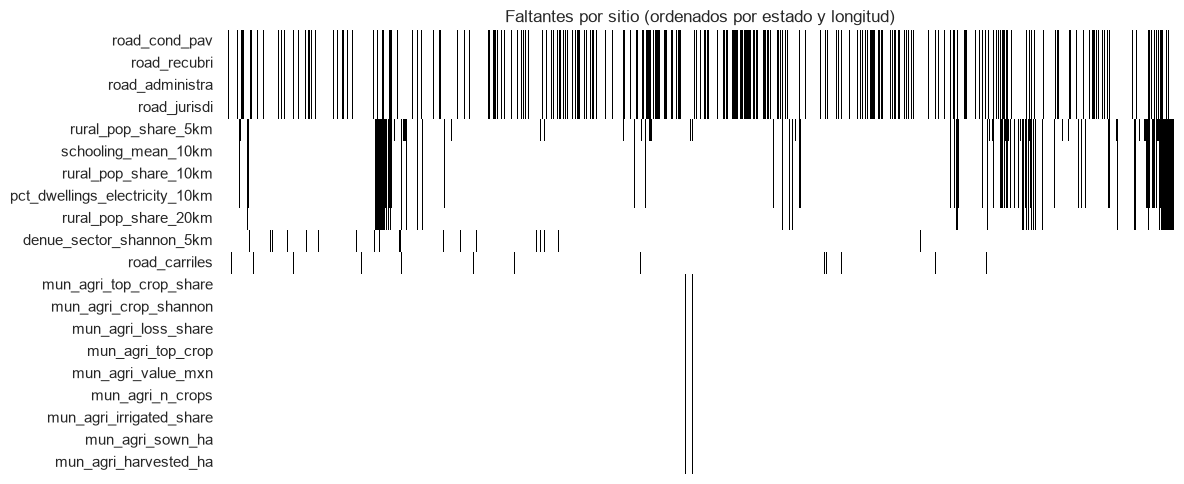

,feature,mediana log_tdpa si falta,si no falta,p_value
0,road_cond_pav,9.7584,9.1384,0.0000
1,road_recubri,9.7584,9.1384,0.0000
2,road_administra,9.7584,9.1384,0.0000
3,road_jurisdi,9.7584,9.1384,0.0000
4,rural_pop_share_5km,9.7322,9.2418,0.0002
5,schooling_mean_10km,9.7322,9.2586,0.0007
6,rural_pop_share_10km,9.7322,9.2586,0.0007
7,pct_dwellings_electricity_10km,9.7322,9.2586,0.0007
8,rural_pop_share_20km,9.9953,9.2816,0.0065
9,denue_sector_shannon_5km,7.6852,9.3219,0.0000


In [5]:
miss = df[feats].isna().mean().mul(100).round(1).sort_values(ascending=False)
miss = miss[miss > 0].to_frame("% faltante")
display(miss.join(prov.set_index("feature_name")[["source", "spatial_resolution"]]))
if len(miss):
    fig, ax = plt.subplots(figsize=(12, 5))
    order = df.sort_values(["group_state", "lon"]).index
    sns.heatmap(df.loc[order, miss.index].isna().T, cbar=False, cmap="Greys", ax=ax, xticklabels=False)
    ax.set_title("Faltantes por sitio (ordenados por estado y longitud)"); savefig("01_missing_pattern")
    # ¿La ausencia depende del objetivo? (si sí, imputar sin cuidado sesga el modelo)
    rows = []
    for c in miss.index:
        a, b = df.loc[df[c].isna(), TARGET], df.loc[df[c].notna(), TARGET]
        if len(a) > 2 and len(b) > 2:
            rows.append([c, a.median(), b.median(), stats.mannwhitneyu(a, b).pvalue])
    display(pd.DataFrame(rows, columns=["feature", "mediana log_tdpa si falta", "si no falta", "p_value"]).round(4))

## 2. Variable objetivo
### 2.1 Distribución, sesgo y transformación

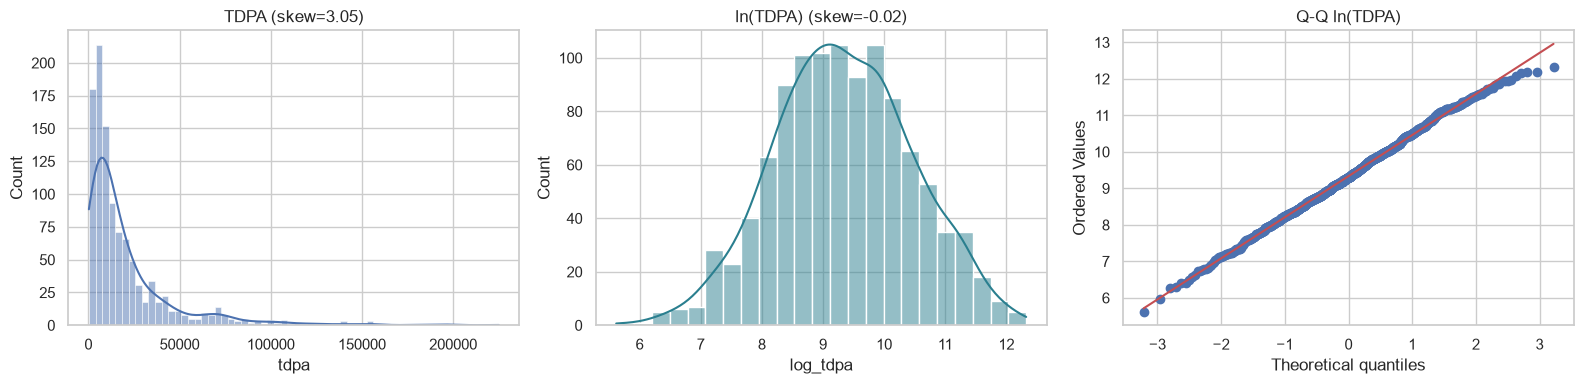

Shapiro-Wilk ln(TDPA): p = 0.2015
Atípicos del objetivo (IQR, escala log): 3


,site_id,carretera,lugar_base,tdpa,te_list
125,S0125,Taxco - Ixcateopan,Ixcateopan,395.0,1
346,S0346,T. C. (Ixtlahuaca de Rayón - Naucalpan) - Temoaya,T. C. Ixtlahuaca de Rayón - Naucalpan,275.0,3
362,S0362,T. C. (Toluca - Palmillas) - Agostadero,El Agostadero,534.0,1


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["tdpa"], kde=True, ax=ax[0]); ax[0].set_title(f"TDPA (skew={df['tdpa'].skew():.2f})")
sns.histplot(df[TARGET], kde=True, ax=ax[1], color="#2a7f8f"); ax[1].set_title(f"ln(TDPA) (skew={df[TARGET].skew():.2f})")
stats.probplot(df[TARGET], dist="norm", plot=ax[2]); ax[2].set_title("Q-Q ln(TDPA)")
savefig("02_target_distribution")
print("Shapiro-Wilk ln(TDPA): p =", round(stats.shapiro(df[TARGET]).pvalue, 4))
q1, q3 = df[TARGET].quantile([.25, .75]); iqr = q3 - q1
out = df[(df[TARGET] < q1 - 1.5*iqr) | (df[TARGET] > q3 + 1.5*iqr)]
print(f"Atípicos del objetivo (IQR, escala log): {len(out)}")
display(out[["site_id", "carretera", "lugar_base", "tdpa", "te_list"]])

### 2.2 ¿Desequilibrio? Distribución del objetivo por grupos
Es regresión, así que no hay clases; el equivalente es revisar si algunos grupos (tipo de red, cuota, estado)
están sobre o subrepresentados, porque eso afecta la validación agrupada y la transferencia al corredor.

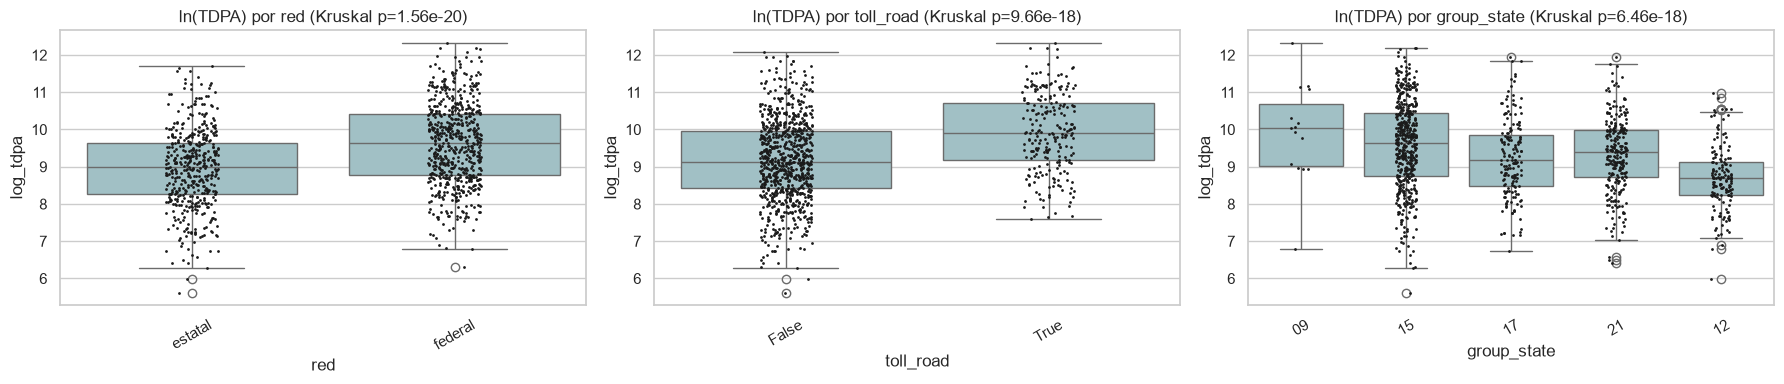

,count,mean,median
toll_road,,,
False,845,9.18,9.14
True,230,9.92,9.90


In [7]:
by = [c for c in ["red", "toll_road", "group_state"] if c in df]
fig, ax = plt.subplots(1, len(by), figsize=(6*len(by), 4), squeeze=False)
for a, b in zip(ax.flat, by):
    sns.boxplot(data=df, x=b, y=TARGET, ax=a, color="#9bc4cb"); sns.stripplot(data=df, x=b, y=TARGET, ax=a, color="k", size=2)
    groups = [g[TARGET] for _, g in df.groupby(b) if len(g) > 1]
    p = stats.kruskal(*groups).pvalue if len(groups) > 1 else np.nan
    a.set_title(f"ln(TDPA) por {b} (Kruskal p={p:.3g})"); a.tick_params(axis="x", rotation=30)
savefig("03_target_by_group")
display(df.groupby("toll_road")[TARGET].agg(["count", "mean", "median"]).round(2))

## 3. Features explicativas integradas
Se incluyen atributos de carretera, intersecciones (RNC), población y vivienda alrededor del sitio (Censo ITER), y actividad agrícola municipal (SIAP). También se incluyen clima y radiación solar (NASA POWER, malla regional de ~0.5°) y establecimientos económicos a 5 km (DENUE), agregados por sector SCIAN.

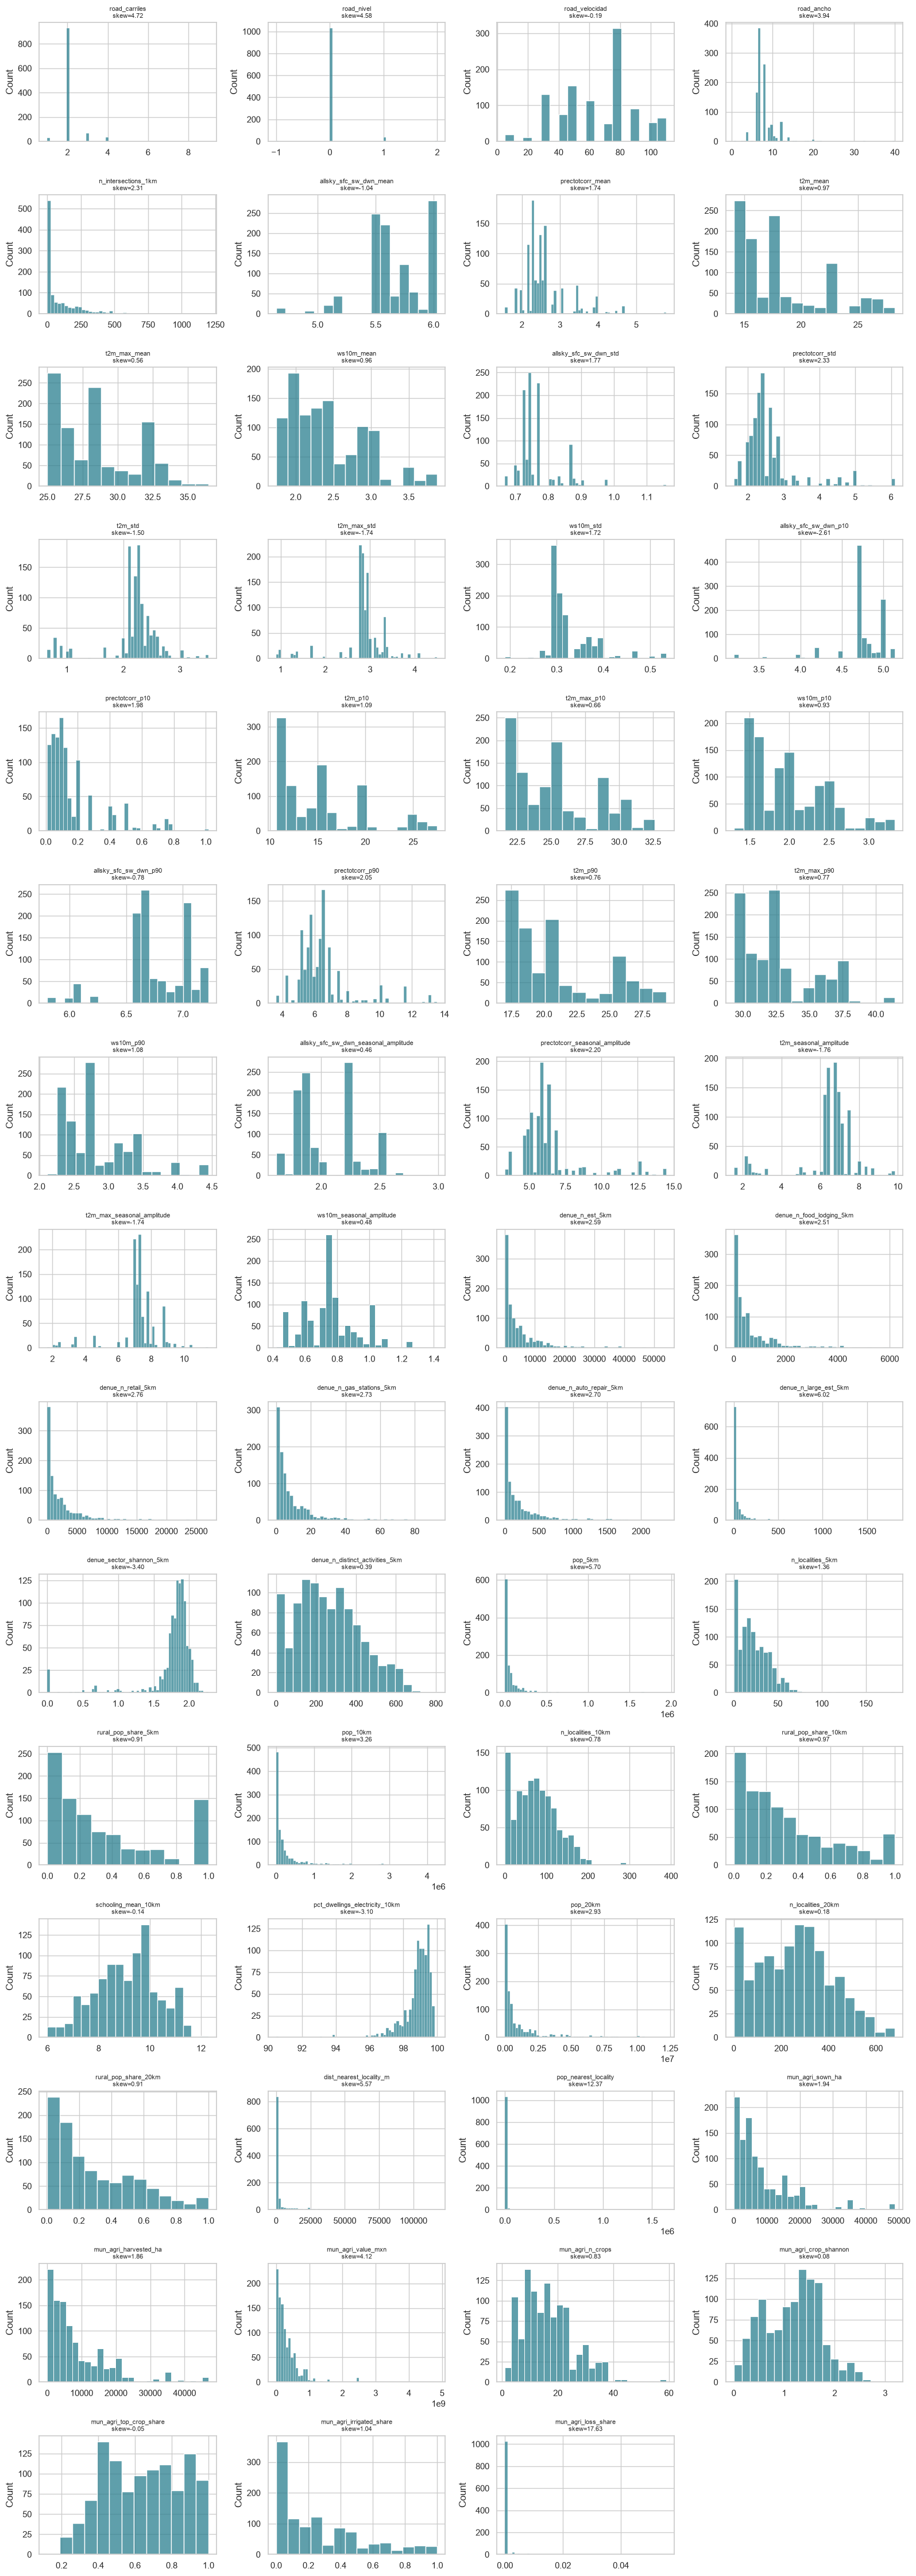

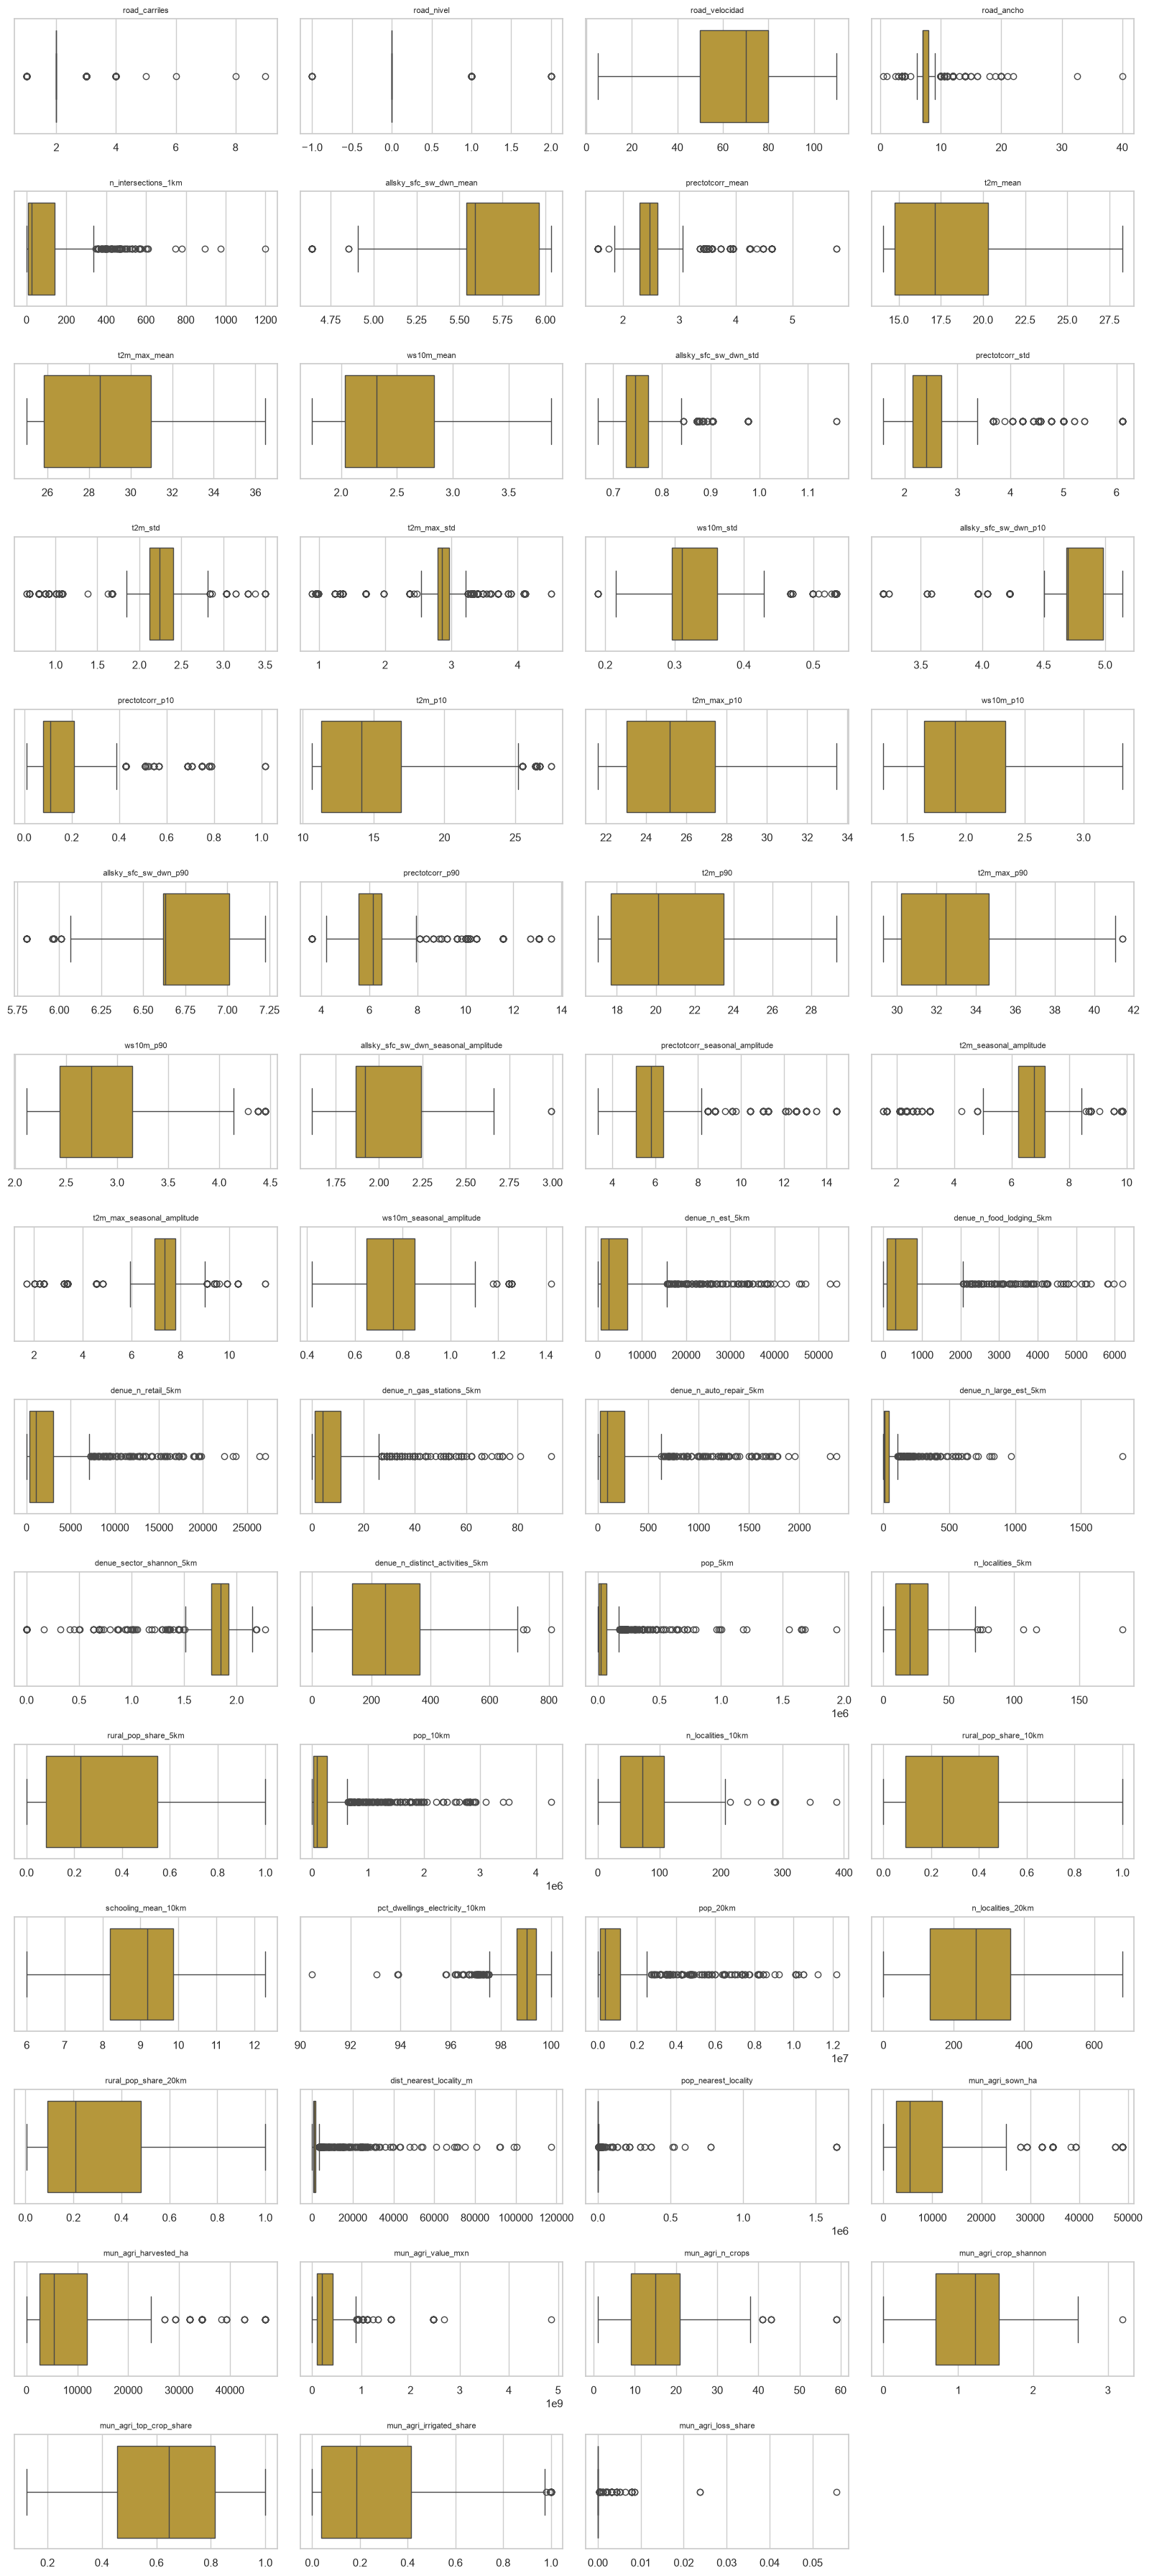

,skew,skew_log1p
road_carriles,4.72,1.98
road_nivel,4.58,NaN
road_velocidad,-0.19,-1.39
road_ancho,3.94,0.24
n_intersections_1km,2.31,-0.00
allsky_sfc_sw_dwn_mean,-1.04,-1.24
prectotcorr_mean,1.74,1.16
t2m_mean,0.97,0.72
t2m_max_mean,0.56,0.45
ws10m_mean,0.96,0.68


In [8]:
show = [c for c in num if not c.endswith(("_min_month", "_missing_pct"))]
if show:
    n = len(show); nc = 4; nr = int(np.ceil(n / nc))
    fig, axes = plt.subplots(nr, nc, figsize=(16, 3*nr), squeeze=False)
    for a, c in zip(axes.flat, show):
        sns.histplot(df[c].dropna(), ax=a, color="#2a7f8f"); a.set_title(f"{c}\nskew={df[c].skew():.2f}", fontsize=8); a.set_xlabel("")
    for a in axes.flat[n:]: a.axis("off")
    savefig("04_hist_features")
    fig, axes = plt.subplots(nr, nc, figsize=(16, 2.4*nr), squeeze=False)
    for a, c in zip(axes.flat, show):
        sns.boxplot(x=df[c], ax=a, color="#c9a227"); a.set_title(c, fontsize=8); a.set_xlabel("")
    for a in axes.flat[n:]: a.axis("off")
    savefig("05_box_features")
    sk = pd.DataFrame({"skew": df[show].skew()})
    pos = [c for c in show if (df[c].dropna() >= 0).all()]
    sk.loc[pos, "skew_log1p"] = np.log1p(df[pos]).skew()
    SKEWED = sk.index[sk["skew"].abs() > 1].tolist()
    display(sk.round(2))
else:
    SKEWED = []
    print("Sin features numéricas de entorno: su cálculo para los sitios TOP está pendiente.")

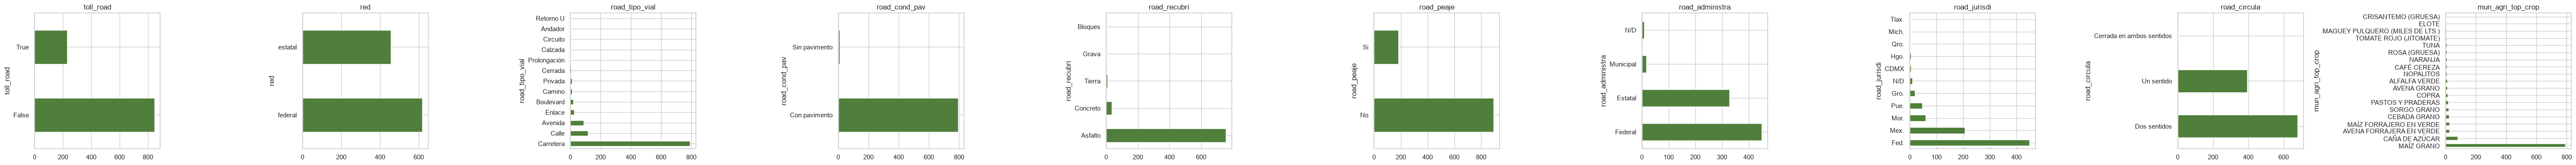

In [9]:
plot_cat = [c for c in cat if df[c].nunique() <= 25]
if plot_cat:
    fig, ax = plt.subplots(1, len(plot_cat), figsize=(6*len(plot_cat), 4), squeeze=False)
    for a, c in zip(ax.flat, plot_cat):
        df[c].astype(str).value_counts().plot.barh(ax=a, color="#4f7f3a"); a.set_title(c)
    savefig("06_bar_categorical")

## 4. Dimensión temporal

Años de aforo: {2025: 1075} -> un solo año: no hay mezcla temporal en el objetivo


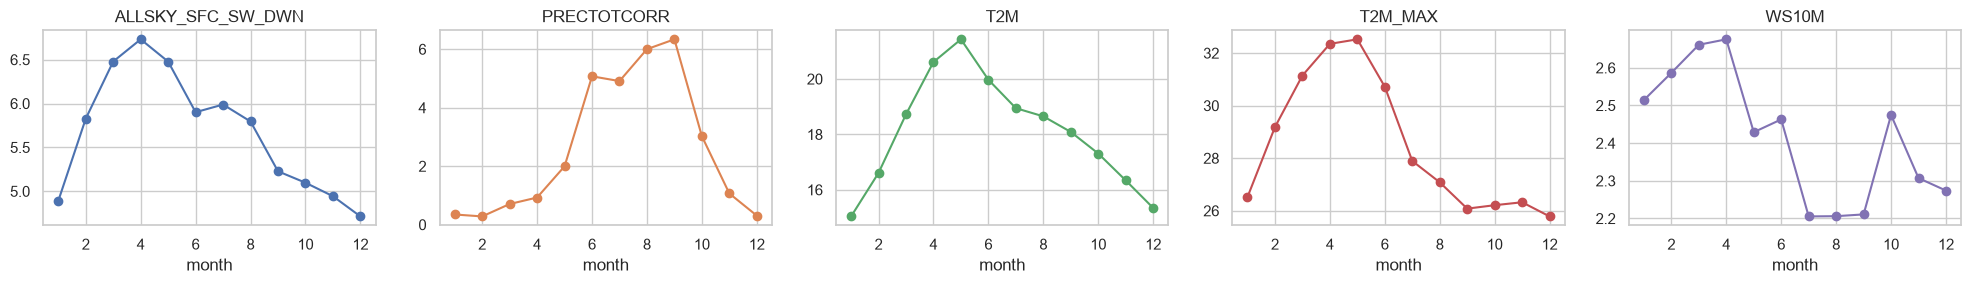

In [10]:
print("Años de aforo:", df["anio"].value_counts().to_dict(), "-> un solo año: no hay mezcla temporal en el objetivo")
f = I / "nasa_power_monthly_sites.csv"
if f.exists():
    nm = pd.read_csv(f); clim = nm.groupby(["parameter", "month"])["value"].mean().unstack(0)
    clim.plot(subplots=True, layout=(1, clim.shape[1]), figsize=(4*clim.shape[1], 3), marker="o", legend=False, title=list(clim.columns))
    savefig("07_nasa_seasonality")

## 5. Análisis bi/multivariante
### 5.1 Correlación de cada feature con el objetivo

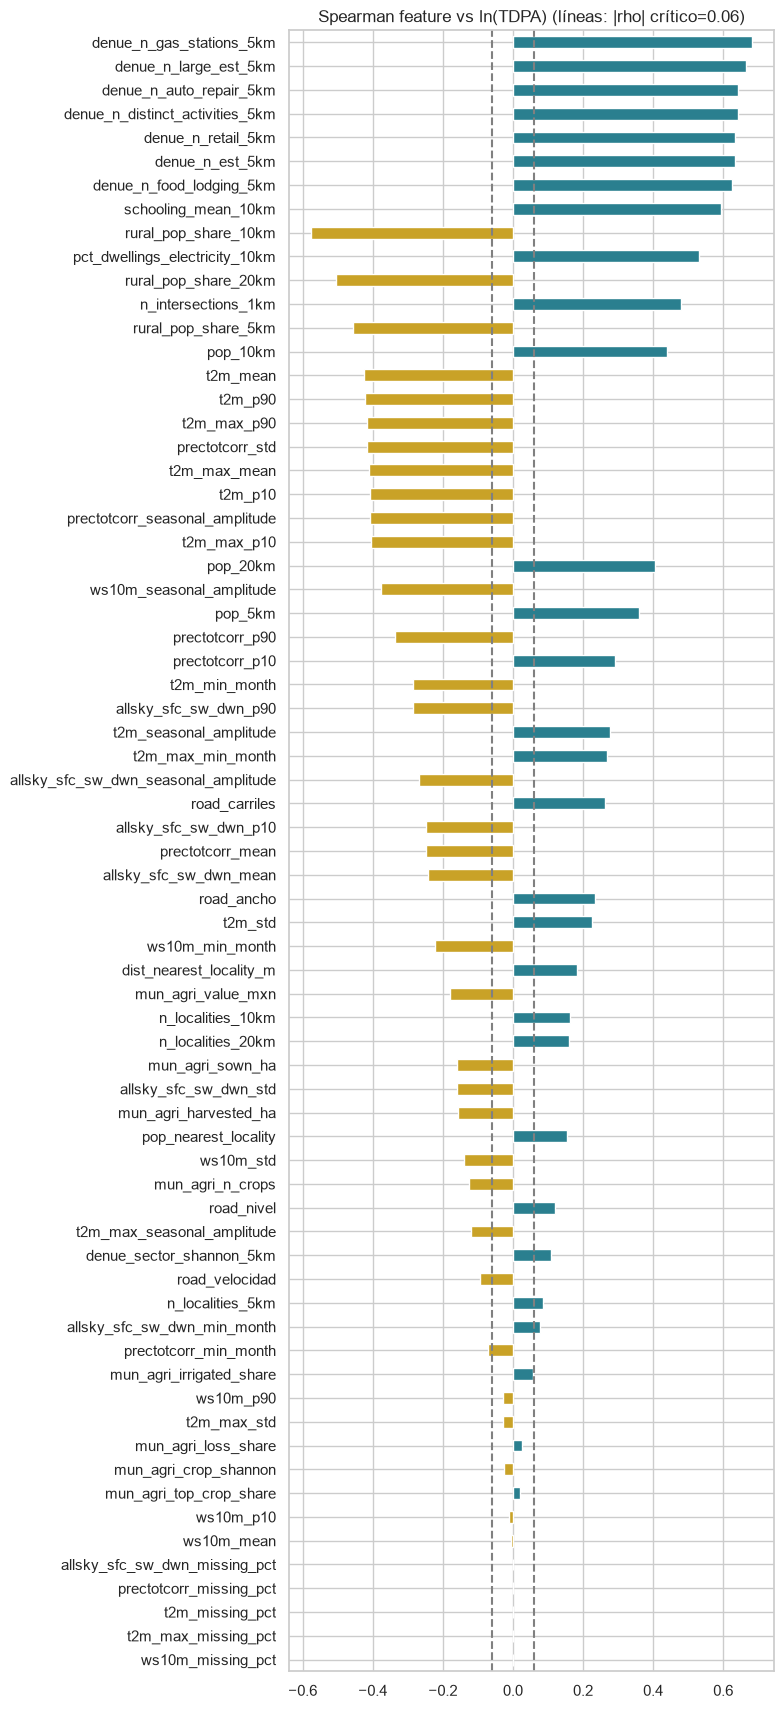

,rho,p,abs
denue_n_gas_stations_5km,0.682,0.0,0.682
denue_n_large_est_5km,0.665,0.0,0.665
denue_n_auto_repair_5km,0.643,0.0,0.643
denue_n_distinct_activities_5km,0.641,0.0,0.641
denue_n_retail_5km,0.634,0.0,0.634
denue_n_est_5km,0.633,0.0,0.633
denue_n_food_lodging_5km,0.625,0.0,0.625
schooling_mean_10km,0.594,0.0,0.594
rural_pop_share_10km,-0.576,0.0,0.576
pct_dwellings_electricity_10km,0.531,0.0,0.531


In [11]:
rel = pd.DataFrame({c: stats.spearmanr(df[c], df[TARGET], nan_policy="omit")[:2] for c in num}, index=["rho", "p"]).T
if len(rel):
    rel["abs"] = rel["rho"].abs(); rel = rel.sort_values("abs", ascending=False)
    r_crit = np.tanh(1.96 / np.sqrt(len(df) - 3))
    fig, ax = plt.subplots(figsize=(8, max(4, .25*len(rel))))
    rel["rho"].iloc[::-1].plot.barh(ax=ax, color=np.where(rel["rho"].iloc[::-1] > 0, "#2a7f8f", "#c9a227"))
    ax.axvline(r_crit, ls="--", c="gray"); ax.axvline(-r_crit, ls="--", c="gray")
    ax.set_title(f"Spearman feature vs ln(TDPA) (líneas: |rho| crítico={r_crit:.2f})"); savefig("08_corr_with_target")
    display(rel.round(3).head(20))
else:
    print("Asociación feature–objetivo pendiente hasta calcular features territoriales para los TOP.")

> **Advertencia de leakage:** este ranking es descriptivo. Si se usa para *seleccionar* features, la selección debe
> repetirse dentro de cada fold de entrenamiento; seleccionar con todos los datos y luego validar infla las métricas.

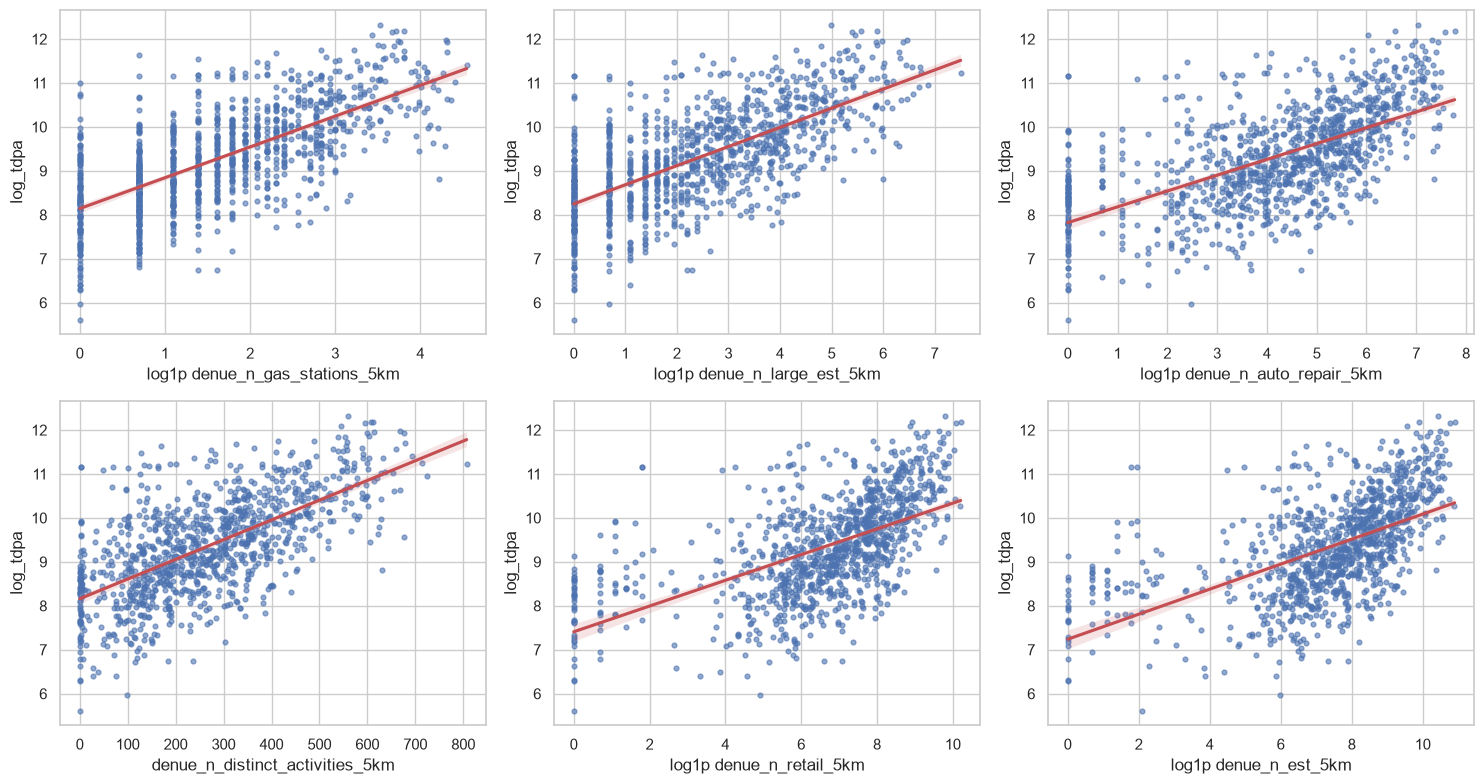

In [12]:
top = rel.index[:6].tolist()
if top:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for a, c in zip(axes.flat, top):
        x = np.log1p(df[c].clip(lower=0)) if c in SKEWED else df[c]
        sns.regplot(x=x, y=df[TARGET], ax=a, scatter_kws={"s": 12, "alpha": .6}, line_kws={"color": "r"})
        a.set_xlabel(("log1p " if c in SKEWED else "") + c)
    for a in axes.flat[len(top):]: a.axis("off")
    savefig("09_scatter_top_features")
else:
    print("Gráficas feature–objetivo pendientes: todavía no hay features territoriales.")

### 5.2 Correlación entre features (multicolinealidad)

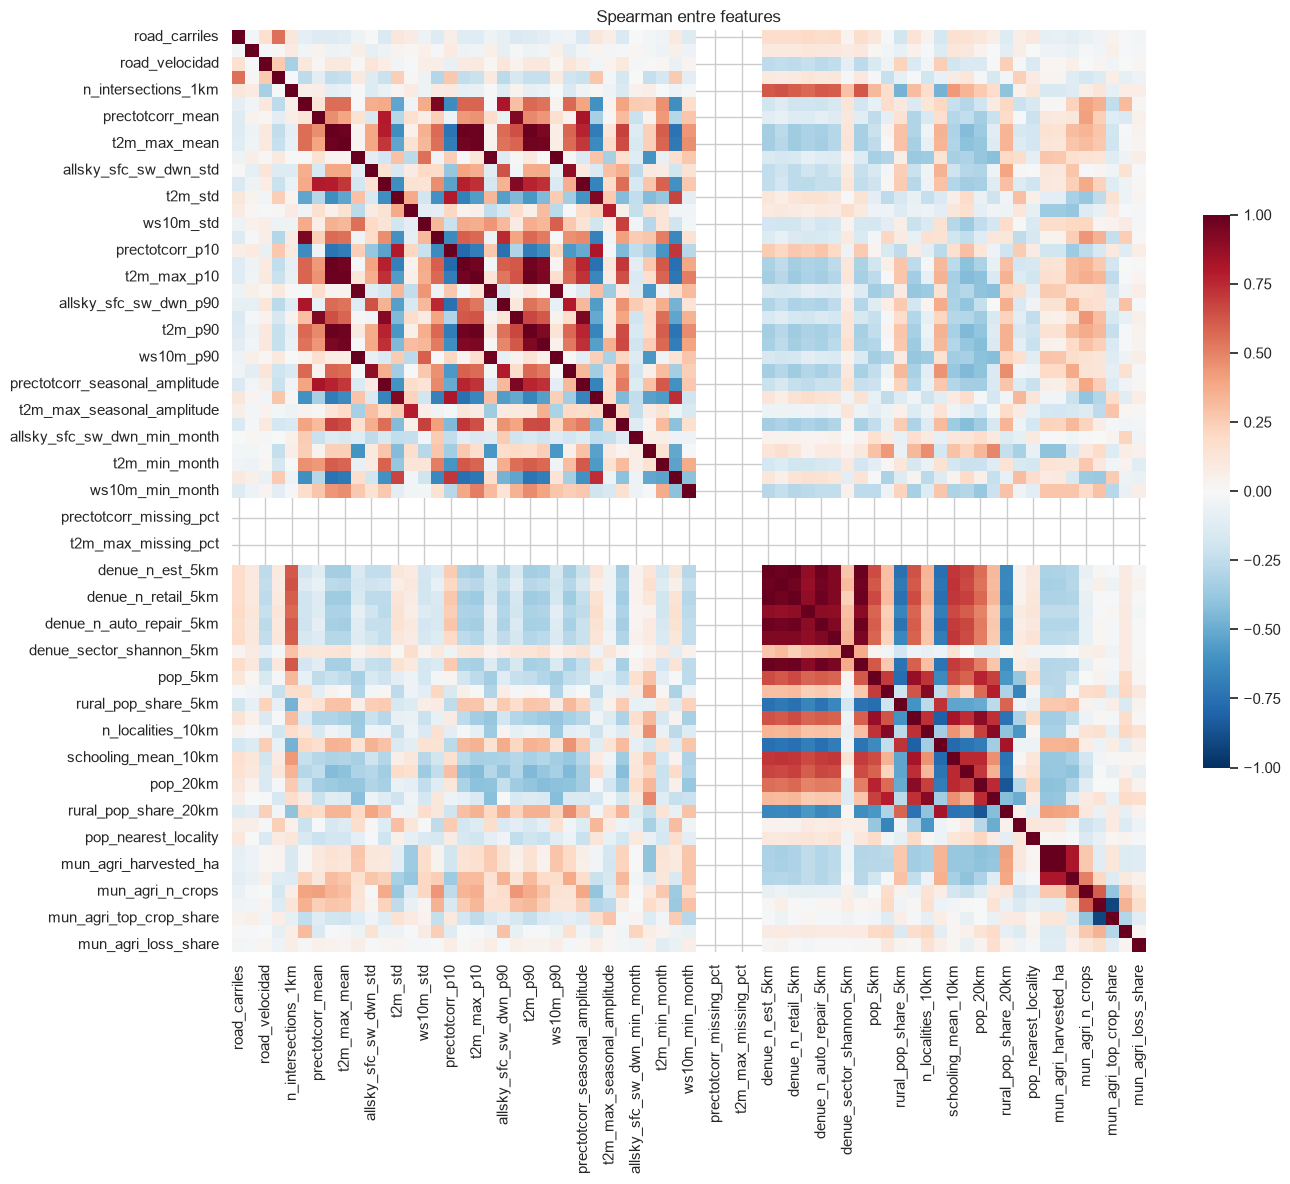

,,rho,abs
mun_agri_sown_ha,mun_agri_harvested_ha,1.000,1.000
denue_n_est_5km,denue_n_retail_5km,0.997,0.997
ws10m_mean,ws10m_p90,0.994,0.994
t2m_mean,t2m_p10,0.991,0.991
t2m_max_p10,t2m_p90,0.991,0.991
prectotcorr_std,prectotcorr_seasonal_amplitude,0.988,0.988
denue_n_est_5km,denue_n_distinct_activities_5km,0.987,0.987
t2m_mean,t2m_p90,0.986,0.986
denue_n_est_5km,denue_n_auto_repair_5km,0.983,0.983
ws10m_mean,ws10m_p10,0.983,0.983


In [13]:
if num:
    sp = df[num].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(14, 12)); sns.heatmap(sp, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": .6})
    ax.set_title("Spearman entre features"); savefig("10_corr_features")
    pairs = sp.where(np.triu(np.ones(sp.shape), 1).astype(bool)).stack().rename("rho").to_frame()
    pairs["abs"] = pairs["rho"].abs(); display(pairs.sort_values("abs", ascending=False).head(15).round(3))
else:
    print("Multicolinealidad pendiente: no se han integrado features territoriales.")

### 5.3 Autocorrelación espacial del objetivo
Comparamos el ln(TDPA) de cada sitio con el de su vecino más cercano según distancia. Si sitios cercanos se parecen
mucho, una partición aleatoria pondría casi el mismo dato en entrenamiento y prueba. La distancia a la que la
correlación cae sugiere el tamaño de bloque para la validación espacial.

,distancia,pares,spearman,semivarianza
0,0-2 km,439,0.579,0.488
1,2-5 km,1121,0.476,0.537
2,5-10 km,2874,0.433,0.652
3,10-25 km,15609,0.223,1.040
4,25-50 km,42325,0.109,1.188
5,50-100 km,129196,0.046,1.250


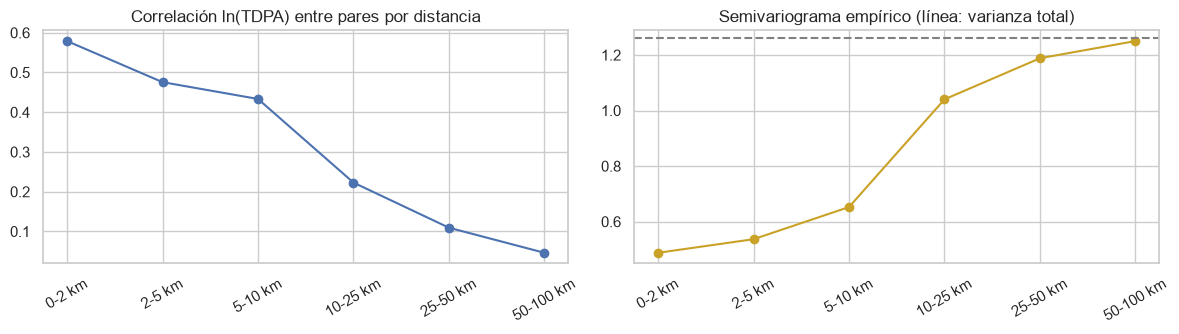

In [14]:
import geopandas as gpd
g = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326").to_crs("EPSG:6372")
xy = np.c_[g.geometry.x, g.geometry.y]; dmat = np.hypot(xy[:, None, 0] - xy[None, :, 0], xy[:, None, 1] - xy[None, :, 1])
np.fill_diagonal(dmat, np.inf); y = df[TARGET].values
bins = [0, 2e3, 5e3, 10e3, 25e3, 50e3, 100e3]; res = []
for lo, hi in zip(bins[:-1], bins[1:]):
    i, j = np.where((dmat > lo) & (dmat <= hi)); m = i < j
    if m.sum() > 10:
        res.append([f"{lo/1e3:.0f}-{hi/1e3:.0f} km", m.sum(), stats.spearmanr(y[i[m]], y[j[m]])[0],
                    0.5 * np.mean((y[i[m]] - y[j[m]])**2)])
ac = pd.DataFrame(res, columns=["distancia", "pares", "spearman", "semivarianza"]); display(ac.round(3))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(ac["distancia"], ac["spearman"], marker="o"); ax[0].set_title("Correlación ln(TDPA) entre pares por distancia")
ax[1].plot(ac["distancia"], ac["semivarianza"], marker="o", c="#c9a227"); ax[1].axhline(np.var(y), ls="--", c="gray")
ax[1].set_title("Semivariograma empírico (línea: varianza total)")
for a in ax: a.tick_params(axis="x", rotation=30)
savefig("11_spatial_autocorrelation")

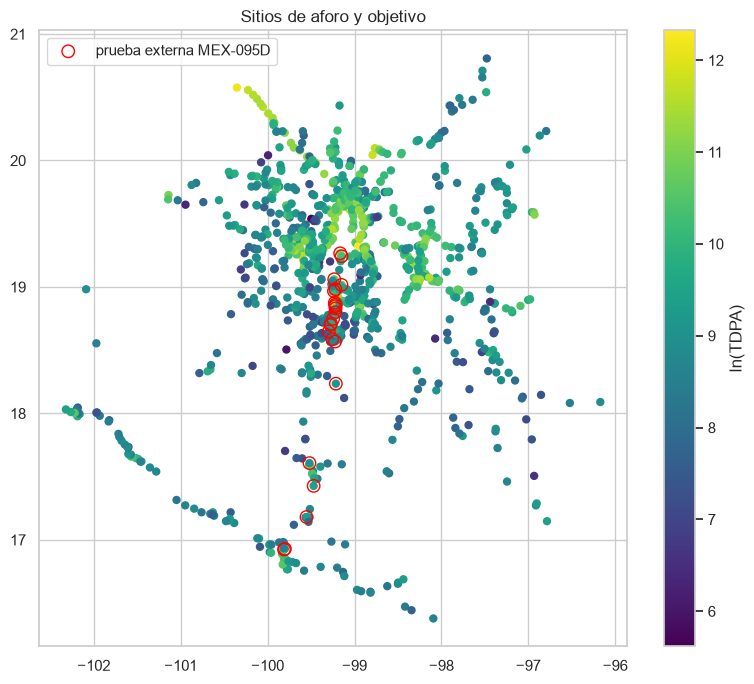

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(df.lon, df.lat, c=df[TARGET], cmap="viridis", s=25)
ax.scatter(test.lon, test.lat, facecolors="none", edgecolors="red", s=80, label="prueba externa MEX-095D")
plt.colorbar(sc, label="ln(TDPA)"); ax.legend(); ax.set_title("Sitios de aforo y objetivo"); savefig("12_map_target")

### 5.4 ¿Los CTN se parecen a los sitios de entrenamiento? (dominio de aplicabilidad)
Si los CTN tienen valores fuera del rango visto en entrenamiento, las predicciones ahí serán extrapolaciones
y deben reportarse con mayor incertidumbre.

In [16]:
if ctn is not None:
    rows = []
    for c in [c for c in num if c in ctn.columns]:
        a, b = train[c].dropna(), ctn[c].dropna()
        if len(a) > 5 and len(b) > 5:
            outside = ((b < a.min()) | (b > a.max())).mean() * 100
            rows.append([c, stats.ks_2samp(a, b).pvalue, outside])
    shift = pd.DataFrame(rows, columns=["feature", "KS p_value", "% CTN fuera de rango de entrenamiento"]).sort_values("KS p_value")
    display(shift.round(4).head(15))

,feature,KS p_value,% CTN fuera de rango de entrenamiento
2,road_velocidad,0.0,0.0
27,t2m_seasonal_amplitude,0.0,0.0
11,prectotcorr_std,0.0,0.0
26,prectotcorr_seasonal_amplitude,0.0,0.0
16,prectotcorr_p10,0.0,0.0
17,t2m_p10,0.0,0.0
21,prectotcorr_p90,0.0,0.0
33,t2m_max_min_month,0.0,0.0
7,t2m_mean,0.0,0.0
22,t2m_p90,0.0,0.0


## 6. Preprocesamiento (exploratorio; en modelado se ajusta sólo con entrenamiento dentro de cada fold)
### 6.1 Faltantes
| Caso | Estrategia | Justificación |
|---|---|---|
| Conteos (población, DENUE, localidades) = 0 | Se conservan | Cero real, no faltante |
| `mun_agri_*` sin registro SIAP | Indicador + mediana | Faltante estructural (municipios urbanos) |
| Variables de Censo en buffers sin localidades o con `*` | Indicador + mediana | Confidencialidad / sin población |
| Cualquier otra numérica | Mediana + indicador `_missing` | Robusta a sesgo; el indicador conserva la información de ausencia |

In [17]:
pre = df.copy(); log = []
for c in [c for c in num if pre[c].isna().any()]:
    pre[f"{c}_missing"] = pre[c].isna().astype(int); n0 = pre[c].isna().sum()
    pre[c] = pre[c].fillna(pre.loc[~pre["is_corridor_test"], c].median())  # mediana SOLO de entrenamiento
    log.append([c, n0, "mediana (entrenamiento) + indicador"])
for c in [c for c in cat if pre[c].isna().any()]:
    n0 = pre[c].isna().sum(); pre[c] = pre[c].fillna("FALTANTE"); log.append([c, n0, "categoría FALTANTE"])
display(pd.DataFrame(log, columns=["variable", "n_imputados", "estrategia"]))

,variable,n_imputados,estrategia
0,road_carriles,14,mediana (entrenamiento) + indicador
1,denue_sector_shannon_5km,19,mediana (entrenamiento) + indicador
2,rural_pop_share_5km,141,mediana (entrenamiento) + indicador
3,rural_pop_share_10km,109,mediana (entrenamiento) + indicador
4,schooling_mean_10km,109,mediana (entrenamiento) + indicador
5,pct_dwellings_electricity_10km,109,mediana (entrenamiento) + indicador
6,rural_pop_share_20km,61,mediana (entrenamiento) + indicador
7,mun_agri_sown_ha,2,mediana (entrenamiento) + indicador
8,mun_agri_harvested_ha,2,mediana (entrenamiento) + indicador
9,mun_agri_value_mxn,2,mediana (entrenamiento) + indicador


### 6.2 Atípicos
No se eliminan sitios: los TDPA extremos (zona metropolitana, libramientos de Cuernavaca) son reales.
Estrategia: objetivo en escala log, `log1p` en features sesgadas y modelos robustos (árboles) o escalado robusto.

In [18]:
rows = []
for c in show:
    s = pre[c]; q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    k = ((s < q1 - 1.5*i) | (s > q3 + 1.5*i)).sum()
    if k: rows.append([c, k, round(100*k/len(s), 1)])
display(pd.DataFrame(rows, columns=["feature", "atípicos IQR", "%"]).sort_values("atípicos IQR", ascending=False))
for c in SKEWED: pre[f"log1p_{c}"] = np.log1p(pre[c].clip(lower=0))

,feature,atípicos IQR,%
9,t2m_max_std,254,23.6
2,road_ancho,217,20.2
39,dist_nearest_locality_m,166,15.4
40,pop_nearest_locality,166,15.4
6,allsky_sfc_sw_dwn_std,149,13.9
5,prectotcorr_mean,147,13.7
8,t2m_std,147,13.7
33,pop_10km,141,13.1
0,road_carriles,133,12.4
20,t2m_seasonal_amplitude,127,11.8


### 6.3 Alta cardinalidad
- `group_route` (carretera) y `group_block25` **no son features**: se usan sólo para agrupar la validación.
- DENUE `Clase_actividad` → agregado a sectores SCIAN y conteos temáticos + diversidad de Shannon.
- Cultivos SIAP → número de cultivos, diversidad y cultivo principal; cultivos con < 5 sitios → `OTROS`.

In [19]:
if "mun_agri_top_crop" in pre:
    vc = pre["mun_agri_top_crop"].value_counts(); rare = vc[vc < 5].index
    pre["mun_agri_top_crop_grp"] = pre["mun_agri_top_crop"].where(~pre["mun_agri_top_crop"].isin(rare), "OTROS")
    print("cultivo principal:", pre["mun_agri_top_crop"].nunique(), "->", pre["mun_agri_top_crop_grp"].nunique(), "categorías")

cultivo principal: 20 -> 18 categorías


## 7. Selección preliminar de características (objetivo 2.1)
Criterios **no supervisados** (no usan el objetivo, por lo que no generan leakage): varianza casi nula y
redundancia |Spearman| > 0.90 entre features. La selección basada en relevancia con el objetivo queda para
el modelado, dentro de cada fold.

In [20]:
cand = [c for c in show]
cv_ = pre[cand].std() / pre[cand].mean().abs().replace(0, np.nan)
low = cv_[cv_ < 0.01].index.tolist(); keep = [c for c in cand if c not in low]
sp2 = pre[keep].corr(method="spearman").abs(); compl = df[keep].notna().mean(); drop = set()
for i, a in enumerate(keep):
    for b in keep[i+1:]:
        if a not in drop and b not in drop and sp2.loc[a, b] > .90:
            drop.add(b if compl[a] >= compl[b] else a)
selected = [c for c in keep if c not in drop] + [c for c in cat]
sel = pd.DataFrame({"feature": cand + cat, "decisión": ["varianza ~0" if c in low else "redundante" if c in drop else "seleccionada" for c in cand + cat]})
display(sel.merge(prov[["feature_name", "class", "source"]], left_on="feature", right_on="feature_name", how="left").drop(columns="feature_name"))
print(f"{len(cand) + len(cat)} -> {len(selected)} features")
cols = ["site_id", "lon", "lat", "tdpa", TARGET, "group_state", "group_route", "group_block25", "is_corridor_test"] + selected + \
       [c for c in pre.columns if c.endswith("_missing") or c.startswith("log1p_") or c.endswith("_grp")]
pre[list(dict.fromkeys(cols))].to_csv(P / "TOP_Model_Table_preprocessed.csv", index=False)
sel.to_csv(ROOT / "06_RESULTS" / "feature_selection_top.csv", index=False)

,feature,decisión,class,source
0,road_carriles,seleccionada,O,INEGI RNC
1,road_nivel,seleccionada,O,INEGI RNC
2,road_velocidad,seleccionada,O,INEGI RNC
3,road_ancho,seleccionada,O,INEGI RNC
4,n_intersections_1km,seleccionada,P,INEGI RNC
...,...,...,...,...
64,road_peaje,seleccionada,O,INEGI RNC
65,road_administra,seleccionada,O,INEGI RNC
66,road_jurisdi,seleccionada,O,INEGI RNC
67,road_circula,seleccionada,O,INEGI RNC


69 -> 48 features


## 8. Diseño de validación (vista previa para el modelado)

In [21]:
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
for gcol in ["group_block25", "group_route"]:
    sizes = [len(te) for _, te in gkf.split(train, groups=train[gcol])]
    print(f"GroupKFold por {gcol}: {train[gcol].nunique()} grupos -> tamaños de fold de prueba {sizes}")
print(f"Prueba externa (MEX-095D, nunca entrena): {len(test)} sitios")

GroupKFold por group_block25: 176 grupos -> tamaños de fold de prueba [211, 211, 210, 210, 210]
GroupKFold por group_route: 240 grupos -> tamaños de fold de prueba [211, 211, 210, 210, 210]
Prueba externa (MEX-095D, nunca entrena): 23 sitios


## 9. Conclusiones
- Se integró la edición SICT 2026 con observaciones de 2025. La tabla reproducida tiene 1,075 sitios con TDPA en cinco estados; todas las observaciones corresponden a 2025.
- La ruta MEX-095D aporta 23 sitios detectados como prueba externa preliminar. Confirmar cobertura espacial/ruta antes de fijar el conjunto de prueba final.
- `log_tdpa` es un objetivo observado, no una etiqueta de idoneidad. El TDPA tiene asimetría 3.054; `ln(TDPA)` tiene asimetría -0.017 y su mediana es 9.299 (TDPA mediano: 10,924 veh/día). La transformación reduce la asimetría; no prueba normalidad por sí sola.
- La tabla tiene 79 features territoriales de RNC, Censo, SIAP, NASA POWER y DENUE. Las features más asociadas con `ln(TDPA)` son `denue_n_gas_stations_5km` (ρ=+0.68), `denue_n_large_est_5km` (ρ=+0.67), `denue_n_auto_repair_5km` (ρ=+0.64), `denue_n_distinct_activities_5km` (ρ=+0.64), `denue_n_retail_5km` (ρ=+0.63). Estas correlaciones son exploratorias y no sustituyen la validación espacial.
- **Recurso solar (NASA POWER):** la radiación media es alta y casi uniforme (4.64–6.03 kWh/m²/día, sólo 28 valores distintos en 1,075 sitios por la malla regional). En esta escala el recurso solar no diferencia sitios: es contexto regional, no medición en sitio, y sus variables deben reducirse a unas pocas para no actuar como identificador de zona.
- **Actividad económica (DENUE):** el número de establecimientos a 5 km tiene correlación de Spearman +0.63 con `ln(TDPA)`. El 1.8% de los sitios no tiene ningún establecimiento en 5 km (INEGI responde "No hay resultados"; es un cero real, no un faltante). En el corredor, los tramos de montaña entre los km 140 y 200 no tienen servicios a 5 km, lo que es relevante para la caracterización de nodos Green Stop.
- Antes del modelado: reducir las variables redundantes de NASA POWER, revisar faltantes, confirmar la asignación del corredor y ejecutar la selección de features dentro de cada fold espacial.